In [1]:
from sedona.spark import SedonaContext
import matplotlib.pyplot as plt

/tmp/ipykernel_322/2442783128.py:9: DeprecationWarning: Importing from 'sedona.stats.clustering.dbscan' is deprecated and will be removed in future versions. Please use 'sedona.spark.stats.clustering.dbscan' instead.
  from sedona.stats.clustering.dbscan import dbscan


In [2]:
%%capture
bucket_name = "apache-sedona-book"

config = SedonaContext.builder().\
            config("spark.hadoop.fs.s3a.access.key", "sedona").\
            config("spark.hadoop.fs.s3a.secret.key", "sedona_password").\
            config("spark.hadoop.fs.s3a.endpoint", "http://minio:9000").\
            config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem").\
            config("spark.hadoop.fs.s3a.path.style.access", "true")

sedona = SedonaContext.create(config.getOrCreate())

sedona.sparkContext.setLogLevel("ERROR")

sc = sedona.sparkContext
sedona.sparkContext.setCheckpointDir("checkpoint")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/08/22 19:03:08 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/08/22 19:03:11 WARN UDTRegistration: Cannot register UDT for org.geotools.coverage.grid.GridCoverage2D, which is already registered.
25/08/22 19:03:11 WARN SimpleFunctionRegistry: The function rs_union_aggr replaced a previously registered function.
25/08/22 19:03:11 WARN UDTRegistration: Cannot register UDT for org.locationtech.jts.geom.Geometry, which is already registered.
25/08/22 19:03:11 WARN UDTRegistration: Cannot register UDT for org.apache.sedona.common.S2Geography.Geography, which is already registered.
25/08/22 19:03:11 WARN UDTRegistration: Cannot register UDT for org.locationtech.jts.index.SpatialIndex, which is already registered.
25/08/22 19:03:11 WARN SimpleFunctionRegistry: The function st_envelop

In [3]:
hotspot_data = sedona.read.format("geoparquet").load(f"s3a://{bucket_name}/hot_spot")

In [4]:
from sedona.spark import dataframe_to_arrow
import geopandas as gpd
 
gdf = gpd.GeoDataFrame.from_arrow(dataframe_to_arrow(hotspot_data))

<Axes: >

<Figure size 1800x600 with 0 Axes>

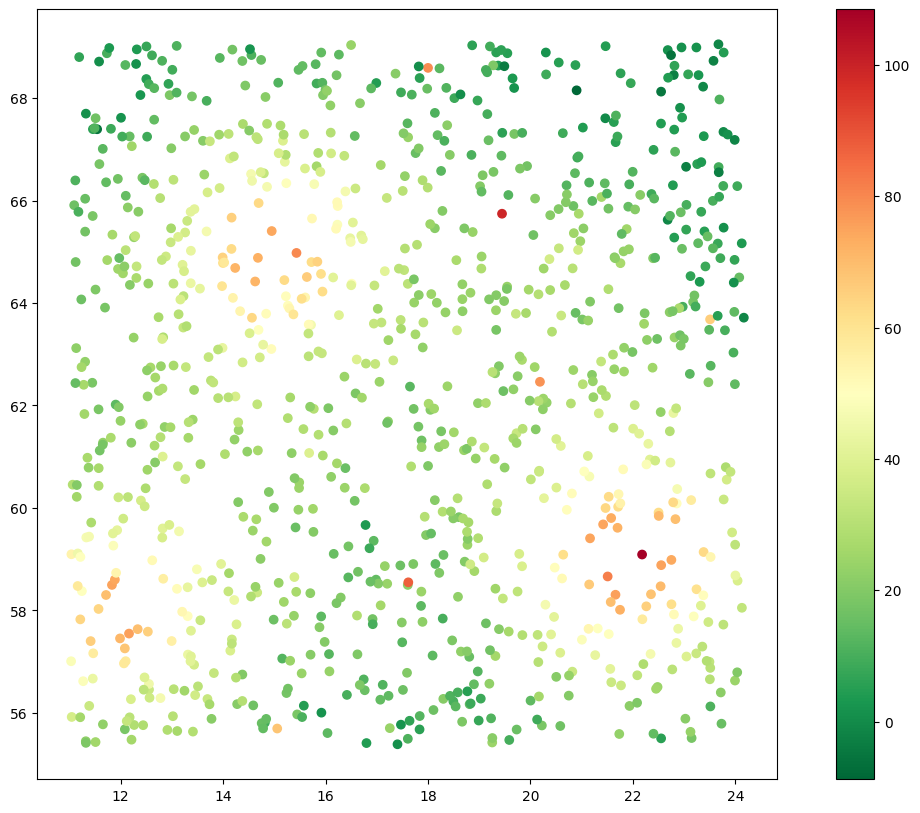

In [5]:
axis = plt.figure(figsize=(18, 6))

gdf.plot(column='value', cmap='RdYlGn_r', figsize=(15, 10), legend=True)

# calculate weights dataframe 

In [6]:
from sedona.stats.weighting import add_distance_band_column
from sedona.stats.hotspot_detection.getis_ord import g_local

/tmp/ipykernel_322/2564312862.py:1: DeprecationWarning: Importing from 'sedona.stats.weighting' is deprecated. Please use 'sedona.spark.stats.weighting' instead.
  from sedona.stats.weighting import add_distance_band_column
/tmp/ipykernel_322/2564312862.py:2: DeprecationWarning: Importing from 'sedona.stats.hotspot_detection.getis_ord' is deprecated. Please use 'sedona.spark.stats.hotspot_detection.getis_ord' instead.
  from sedona.stats.hotspot_detection.getis_ord import g_local


In [7]:
weights_df = add_distance_band_column(
    dataframe=hotspot_data,
    threshold=2.0,
    include_self=True
)

In [8]:
gi_df = g_local(
    dataframe=weights_df,
    x="value",
    star=True
)

# plot result

In [9]:
hotspot_gdf = gpd.GeoDataFrame.from_arrow(dataframe_to_arrow(gi_df))

<Axes: >

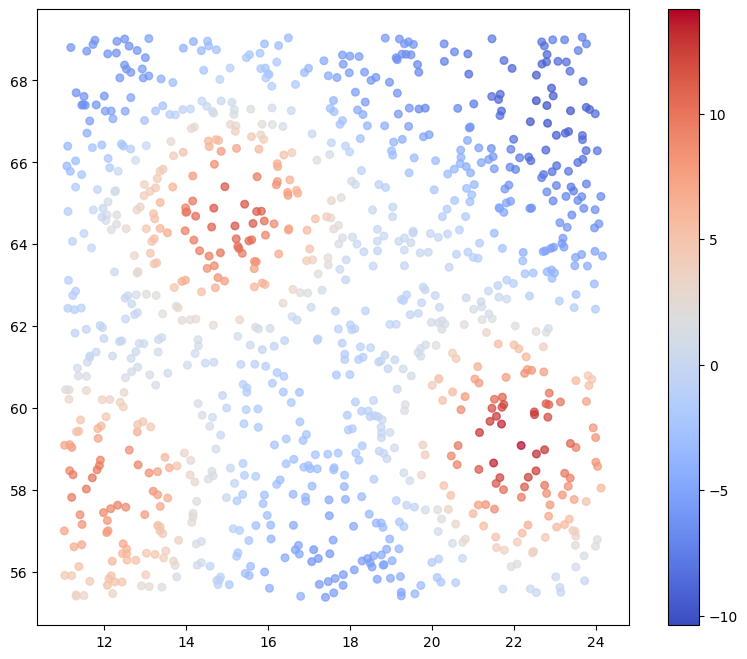

In [10]:
hotspot_gdf.plot(column='Z', cmap='coolwarm', figsize=(10,8), legend=True, marker='o', markersize=30, alpha=0.7)

### 